In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# =====================================================================
# SYSTEM & ENVIRONMENT SETUP
# =====================================================================
sys.path.append('../')  # Point system path to project root
from src.models.simulation_engine import simulate_order

def safe_correlation(y_true, y_pred):
    if np.std(y_pred) == 0 or np.std(y_true) == 0:
        return 0.0
    return np.corrcoef(y_true, y_pred)[0, 1]

In [2]:
print("[1/6] Loading Data and Computing Forecast KPIs...")
# ---------------------------------------------------------------------
# 1. LOAD PREDICTIONS & CALCULATE ML METRICS (RMSE, MAE, ETC.)
# ---------------------------------------------------------------------
df_pred = pd.read_csv('../features/stage_4_input_predictions.csv')
df_pred.columns = df_pred.columns.str.strip()

column_mapping = {'quantity': 'actual_quantity', 'Quantity': 'actual_quantity', 'Actual': 'actual_quantity', 'actual': 'actual_quantity'}
df_pred = df_pred.rename(columns=column_mapping)
df_pred['order_date'] = pd.to_datetime(df_pred['order_date'])

pred_cols = [col for col in df_pred.columns if str(col).startswith('pred_')]
models = {col.replace('pred_', '').replace('_', ' ').title(): col for col in pred_cols}

metrics_data = []
for model_name, col_name in models.items():
    valid_data = df_pred.dropna(subset=['actual_quantity', col_name])
    if not valid_data.empty:
        y_t = valid_data['actual_quantity']
        y_p = valid_data[col_name]
        
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        mae = mean_absolute_error(y_t, y_p)
        r2 = r2_score(y_t, y_p)
        corr = safe_correlation(y_t, y_p)
        
        metrics_data.append({
            'Model': model_name, 
            'RMSE': round(rmse, 2), 
            'MAE': round(mae, 2),
            'R2 Score': round(r2, 4),
            'Correlation': round(corr, 4)
        })



[1/6] Loading Data and Computing Forecast KPIs...


In [3]:
print("[2/6] Loading Phase 2 Baselines & Preparing Real Orders...")
# ---------------------------------------------------------------------
# 2. LOAD BASELINES FROM CSV & PREPARE ROUTING DATA
# ---------------------------------------------------------------------
# Load historical totals directly from Phase 2 CSV (No need to recalculate)
df_base_metrics = pd.read_csv('../src/outputs/powerbi/fact_picking_metrics.csv')

# Trích xuất tổng quãng đường (Total Distance) của ABC và K-Means
dist_abc = df_base_metrics.loc[df_base_metrics['Slotting Strategy'] == 'ABC Layout', 'Total Distance (Meters)'].values[0]
dist_kmeans = df_base_metrics.loc[df_base_metrics['Slotting Strategy'] == 'K-Means Layout', 'Total Distance (Meters)'].values[0]

# Prepare Layout & Transactions
df_layout = pd.read_csv('../src/outputs/powerbi/fact_warehouse_layout.csv')
df_layout['distance_to_io'] = abs(df_layout['x_coordinate']) + abs(df_layout['y_coordinate'])
available_slots = df_layout.sort_values('distance_to_io')[['x_coordinate', 'y_coordinate']].values

df_transactions = pd.read_csv('../data/processed/test_invoices.csv')
valid_skus = set(df_layout['stock_code'].unique())
df_transactions = df_transactions[df_transactions['stock_code'].isin(valid_skus)]
df_transactions['order_date'] = pd.to_datetime(df_transactions['order_date'])
df_transactions['week'] = df_transactions['order_date'].dt.to_period('W')

real_orders = df_transactions.groupby('invoice_no')['stock_code'].apply(list).tolist()
weeks = sorted(df_transactions['week'].unique())

# Reconstruct Baseline Layouts (Required ONLY for the Weekly Time-Series Plot)
df_abc = df_layout.sort_values(by=['abc_class']).reset_index(drop=True)
layout_abc = {row['stock_code']: tuple(available_slots[i]) for i, row in df_abc.iterrows()}

df_kmeans = df_layout.sort_values(by=['cluster_name']).reset_index(drop=True)
layout_kmeans = {row['stock_code']: tuple(available_slots[i]) for i, row in df_kmeans.iterrows()}

print(f"   -> Loaded {len(real_orders):,} orders. Baseline distances: ABC ({dist_abc:,}m), K-Means ({dist_kmeans:,}m).")


[2/6] Loading Phase 2 Baselines & Preparing Real Orders...
   -> Loaded 3,528 orders. Baseline distances: ABC (963,916m), K-Means (953,638m).


In [4]:
print("[3/6] Simulating Distance for AI Models & Weekly Fluctuations...")
# ---------------------------------------------------------------------
# 3. SIMULATE DISTANCE FOR AI MODELS & WEEKLY TRENDS
# ---------------------------------------------------------------------
model_layouts = {}
model_distances = {}
weekly_distances = {m: [] for m in models.keys()}
weekly_distances['ABC Layout'] = []
weekly_distances['K-Means Layout'] = []

# Evaluate Weekly Baseline Distances (For Line Chart)
for w in weeks:
    week_orders = df_transactions[df_transactions['week'] == w].groupby('invoice_no')['stock_code'].apply(list).tolist()
    if len(week_orders) > 0:
        weekly_distances['ABC Layout'].append(sum(simulate_order(o, layout_abc) for o in week_orders) / len(week_orders))
        weekly_distances['K-Means Layout'].append(sum(simulate_order(o, layout_kmeans) for o in week_orders) / len(week_orders))
    else:
        weekly_distances['ABC Layout'].append(0)
        weekly_distances['K-Means Layout'].append(0)

# Simulate ALL AI Models
for model_name, col_name in tqdm(models.items(), desc="Evaluating AI Models"):
    # Ranking items based on forecast
    df_ai = df_pred.groupby('stock_code')[col_name].sum().reset_index()
    df_ai['rank'] = df_ai[col_name].rank(ascending=False, method='first')
    df_ai = df_ai.sort_values('rank').reset_index(drop=True)
    
    # Generate Layout
    current_layout = {row['stock_code']: tuple(available_slots[idx]) for idx, row in df_ai.iterrows() if idx < len(available_slots)}
    model_layouts[model_name] = current_layout
    
    # Calculate TOTAL distance
    model_distances[model_name] = sum(simulate_order(order, current_layout) for order in real_orders)
    
    # Calculate WEEKLY distance
    for w in weeks:
        week_orders = df_transactions[df_transactions['week'] == w].groupby('invoice_no')['stock_code'].apply(list).tolist()
        if len(week_orders) > 0:
            weekly_distances[model_name].append(sum(simulate_order(o, current_layout) for o in week_orders) / len(week_orders))
        else:
            weekly_distances[model_name].append(0)

[3/6] Simulating Distance for AI Models & Weekly Fluctuations...


Evaluating AI Models: 100%|██████████| 7/7 [00:16<00:00,  2.35s/it]


In [ ]:
print("[4/6] Merging Metrics and Identifying the Champion Model...")
# ---------------------------------------------------------------------
# 4. MERGE DISTANCES INTO METRICS TABLE & EXPORT
# ---------------------------------------------------------------------
for row in metrics_data:
    row['Total Travel Distance (m)'] = model_distances[row['Model']]

df_metrics = pd.DataFrame(metrics_data).sort_values(by='Total Travel Distance (m)')

# Identify Champion Model
champion_name = df_metrics.iloc[0]['Model']
champion_dist = df_metrics.iloc[0]['Total Travel Distance (m)']
layout_champion = model_layouts[champion_name]

print(f"\n🏆 CHAMPION MODEL DETECTED: {champion_name}")
print(f"   -> Minimum Travel Distance: {champion_dist:,.0f} meters")

# Export Comprehensive Evaluation Matrix
os.makedirs('../src/outputs/reports/', exist_ok=True)
os.makedirs('../src/outputs/powerbi/', exist_ok=True)

df_metrics.to_csv('../src/outputs/reports/model_evaluation_metrics.csv', index=False)
df_metrics.to_csv('../src/outputs/powerbi/final_evaluation_metrics.csv', index=False)

# =====================================================================
# Export Champion Layout Map
# =====================================================================
final_map_data = []
for sku, coords in layout_champion.items():
    final_map_data.append({
        'stock_code': sku,
        'x_coordinate': int(coords[0]), # Ép kiểu về số nguyên chuẩn
        'y_coordinate': int(coords[1])  # Ép kiểu về số nguyên chuẩn
    })

df_final_map = pd.DataFrame(final_map_data)
df_final_map.to_csv('../src/outputs/powerbi/final_ai_slotting_map.csv', index=False)
# =====================================================================

# Export Champion Velocity Rank (For Presentation Slide)
df_champion_rank = df_pred.groupby('stock_code')[models[champion_name]].sum().reset_index()
df_champion_rank['Velocity_Rank'] = df_champion_rank[models[champion_name]].rank(ascending=False, method='first')
df_champion_rank.columns = ['SKU', 'Predicted_Demand', 'Velocity_Rank']
df_champion_rank.sort_values('Velocity_Rank').to_csv('../src/outputs/reports/champion_velocity_rank.csv', index=False)

display(df_metrics)

[4/6] Merging Metrics and Identifying the Champion Model...

🏆 CHAMPION MODEL DETECTED: Ridge Regression
   -> Minimum Travel Distance: 807,490 meters


,Model,RMSE,MAE,R2 Score,Correlation,Total Travel Distance (m)
1,Ridge Regression,58.92,14.04,0.1900,0.4858,807490
0,Multiple Linear,58.92,14.04,0.1900,0.4858,807542
4,Xgboost,57.89,13.74,0.2180,0.4937,808250
2,Random Forest,58.09,13.85,0.2127,0.4760,808252
3,Lightgbm,58.08,13.69,0.2128,0.4952,808864
6,Naive Baseline,80.82,20.65,-0.5240,0.2004,810282
5,Lstm,62.07,14.80,0.1010,0.3934,817630



[5/6] Generating Performance Comparison Bar Chart...


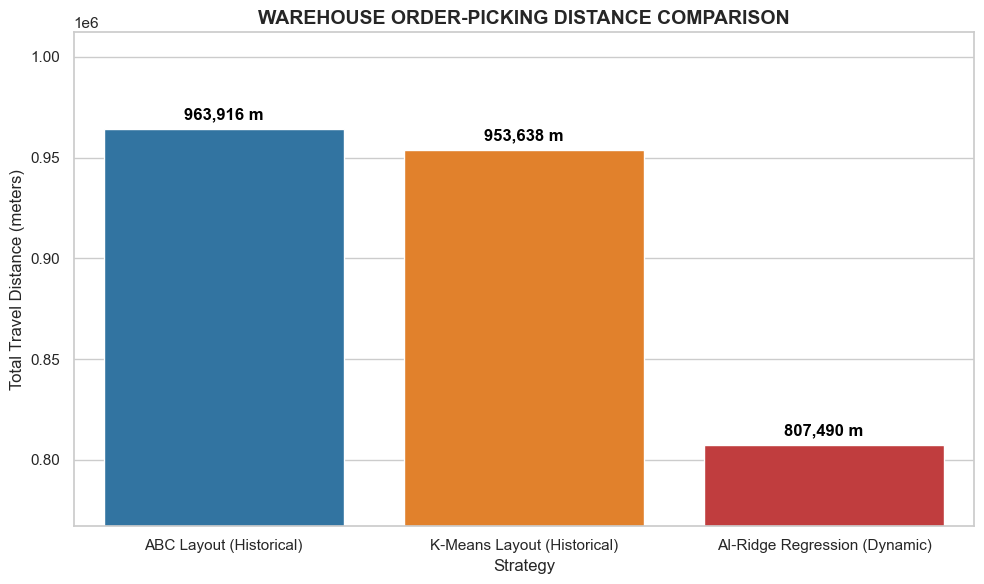

✅ IMPACT: AI-Ridge Regression reduced walking distance by an additional 16.23% compared to ABC Layout.


In [6]:
print("\n[5/6] Generating Performance Comparison Bar Chart...")
# ---------------------------------------------------------------------
# 5. VISUALIZE TOTAL DISTANCE (CHAMPION VS BASELINES)
# ---------------------------------------------------------------------
results = pd.DataFrame({
    'Strategy': ['ABC Layout (Historical)', 'K-Means Layout (Historical)', f'AI-{champion_name} (Dynamic)'],
    'Total Distance (m)': [dist_abc, dist_kmeans, champion_dist]
})

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x='Strategy', y='Total Distance (m)', data=results, palette=['#1f77b4', '#ff7f0e', '#d62728'])

plt.title('WAREHOUSE ORDER-PICKING DISTANCE COMPARISON', fontsize=14, fontweight='bold')
plt.ylabel('Total Travel Distance (meters)', fontsize=12)

plt.ylim(results['Total Distance (m)'].min() * 0.95, results['Total Distance (m)'].max() * 1.05)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} m", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='black',
                xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
os.makedirs('../src/outputs/images/', exist_ok=True)
plt.savefig('../src/outputs/images/4_2_routing_simulation_comparison.png', dpi=300)
plt.show()

improvement = ((dist_abc - champion_dist) / dist_abc) * 100
print(f"✅ IMPACT: AI-{champion_name} reduced walking distance by an additional {improvement:.2f}% compared to ABC Layout.")

[6/6] Generating Time-Series Plot (Weekly Fluctuations)...


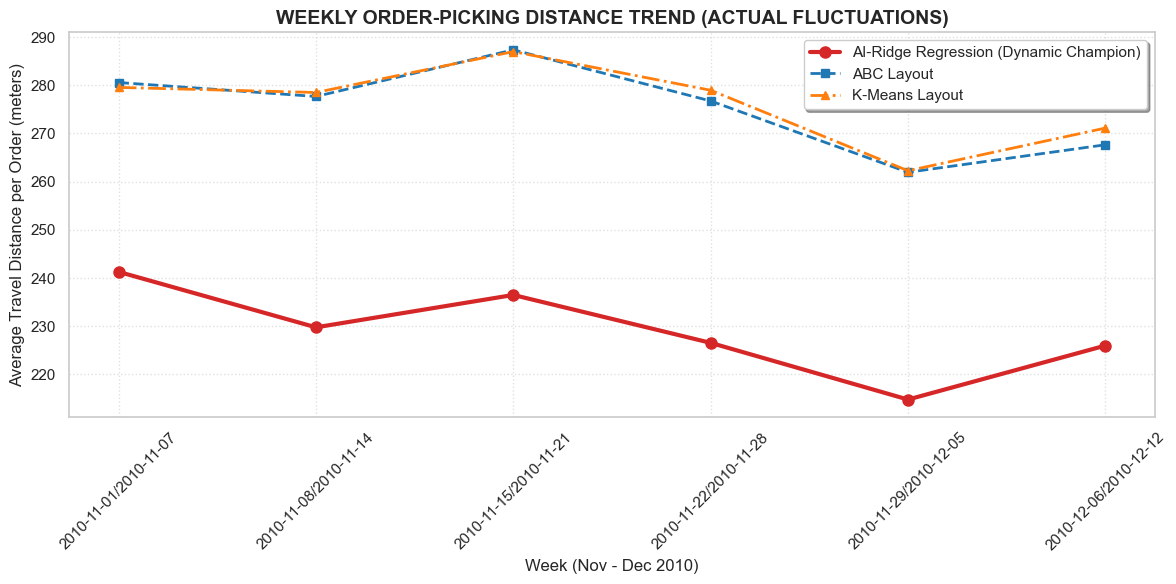

✅ ALL EXPORTS COMPLETED SUCCESSFULLY!


In [7]:
print("[6/6] Generating Time-Series Plot (Weekly Fluctuations)...")
# ---------------------------------------------------------------------
# 6. VISUALIZE TIME-SERIES ADAPTABILITY
# ---------------------------------------------------------------------
plt.figure(figsize=(12, 6))

plt.plot([str(w) for w in weeks], weekly_distances[champion_name], marker='o', markersize=8, 
         linewidth=3, label=f'AI-{champion_name} (Dynamic Champion)', color='#d62728')
plt.plot([str(w) for w in weeks], weekly_distances['ABC Layout'], marker='s', markersize=6, 
         linewidth=2, linestyle='--', label='ABC Layout', color='#1f77b4')
plt.plot([str(w) for w in weeks], weekly_distances['K-Means Layout'], marker='^', markersize=6, 
         linewidth=2, linestyle='-.', label='K-Means Layout', color='#ff7f0e')

plt.title('WEEKLY ORDER-PICKING DISTANCE TREND (ACTUAL FLUCTUATIONS)', fontsize=14, fontweight='bold')
plt.xlabel('Week (Nov - Dec 2010)', fontsize=12)
plt.ylabel('Average Travel Distance per Order (meters)', fontsize=12)

plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)
plt.xticks(rotation=45) 
plt.tight_layout()

plt.savefig('../src/outputs/images/4_3_time_series_real_fluctuations.png', dpi=300)
plt.show()

print("✅ ALL EXPORTS COMPLETED SUCCESSFULLY!")